Using Colab cache for faster access to the 'oranges-vs-grapefruit' dataset.
Dataset Loaded!
Shape: (10000, 6)
     name  diameter  weight  red  green  blue
0  orange      2.96   86.76  172     85     2
1  orange      3.91   88.05  166     78     3
2  orange      4.42   95.17  156     81     2
3  orange      4.47   95.60  163     81     4
4  orange      4.48   95.76  161     72     9

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  object 
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 468.9+ KB
None

STATISTIK DESKRIPTIF
           diameter        weight           red         green          blue
count  10000.0

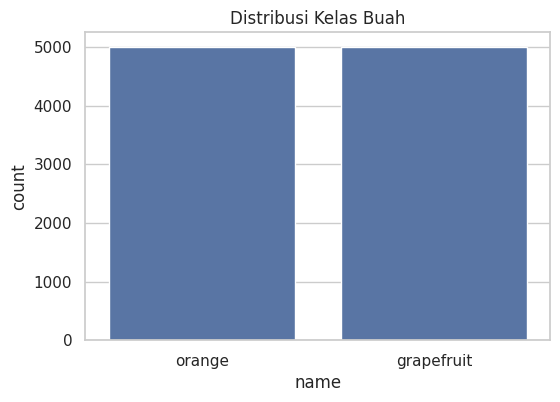

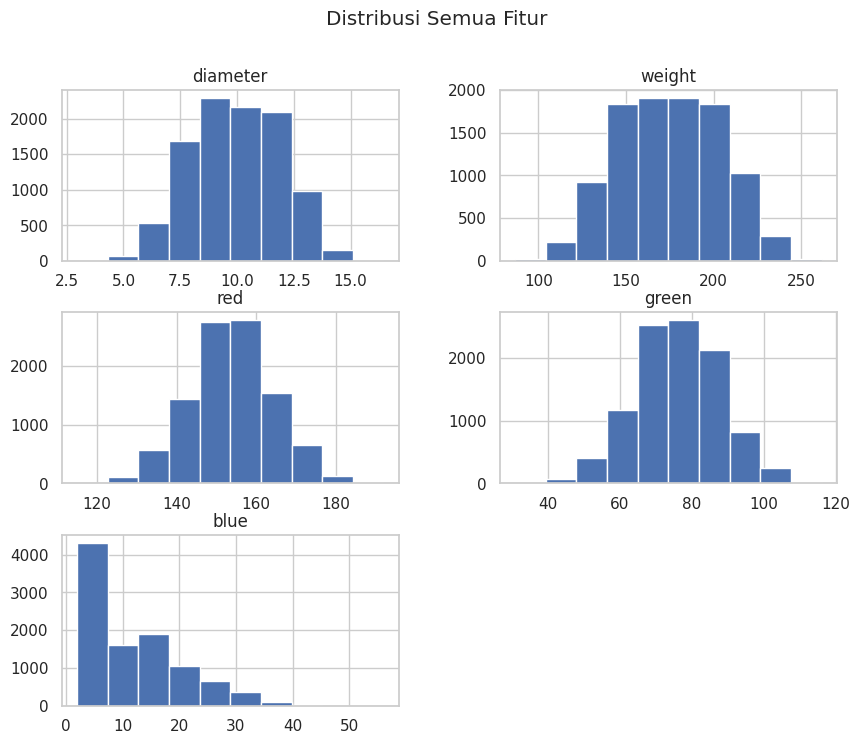

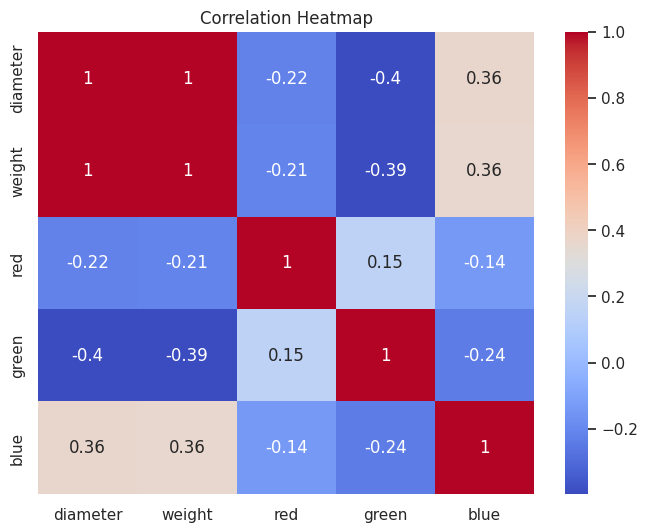

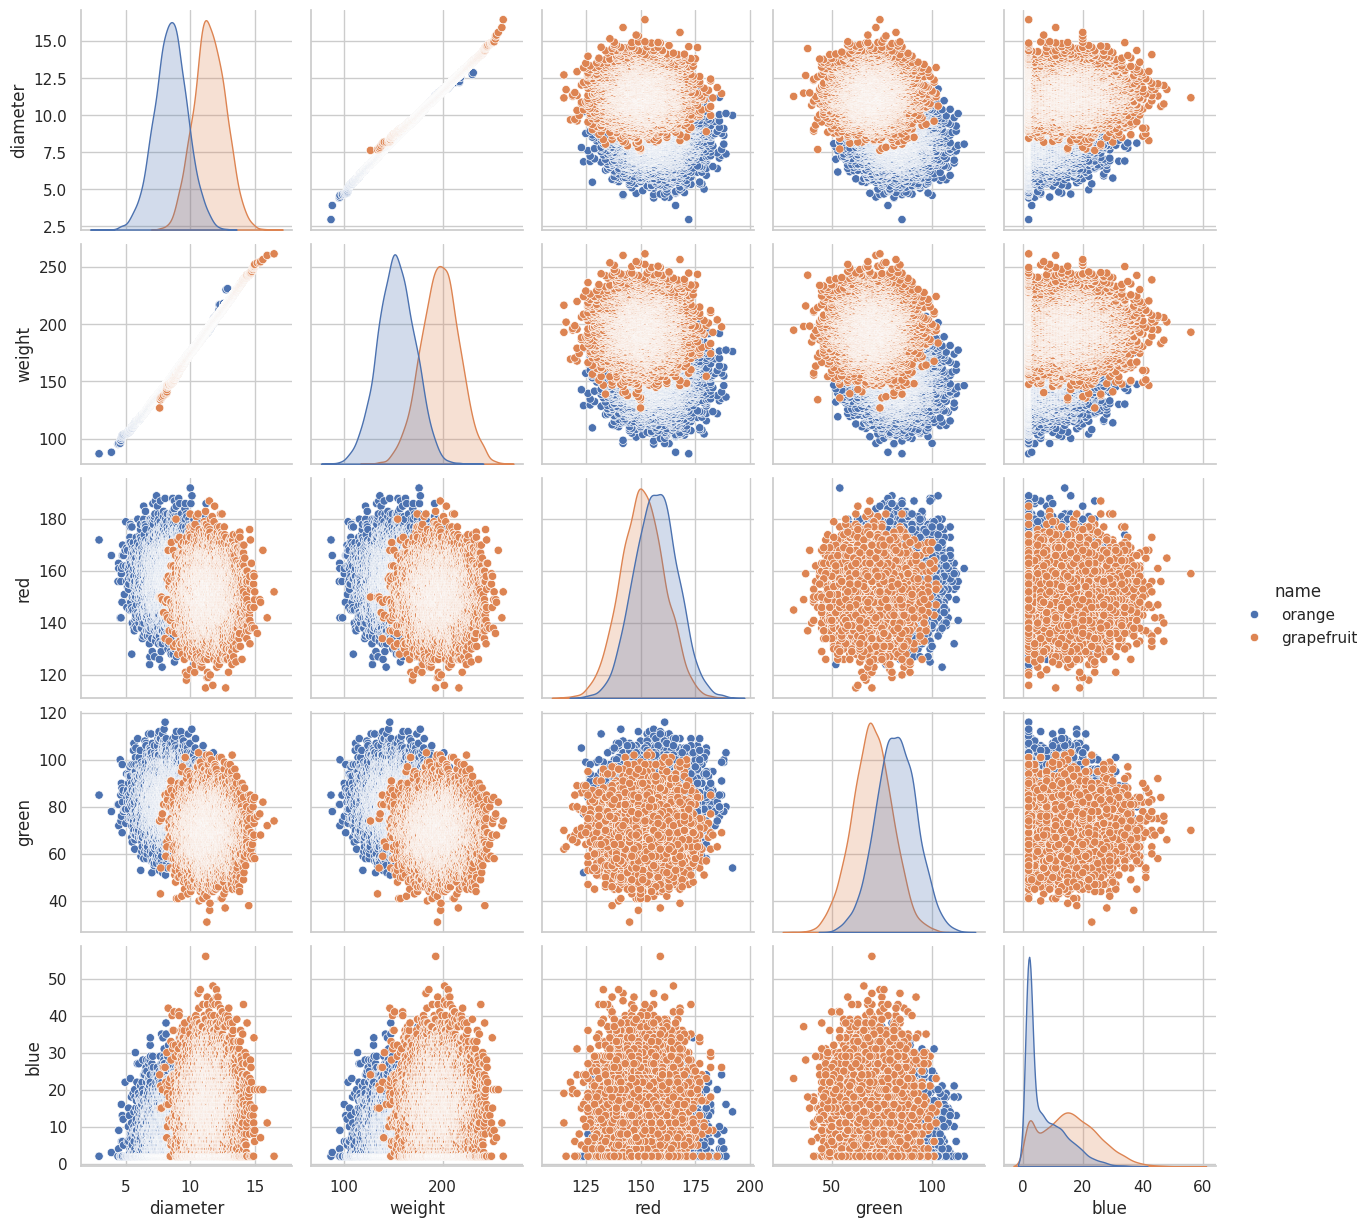

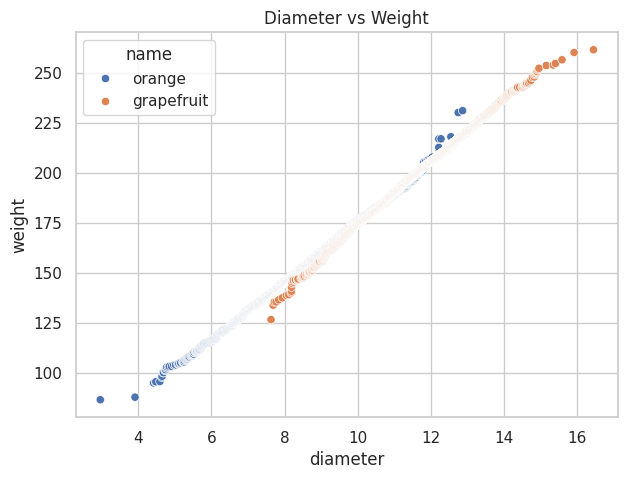


=== CROSS VALIDATION ===
Decision Tree: 0.9359 (+/- 0.0077)
Naive Bayes: 0.9200 (+/- 0.0054)
SVM: 0.9326 (+/- 0.0028)

Best Model: Decision Tree

=== EVALUATION ===
Accuracy: 0.946
              precision    recall  f1-score   support

  grapefruit       0.95      0.94      0.95      1000
      orange       0.94      0.95      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



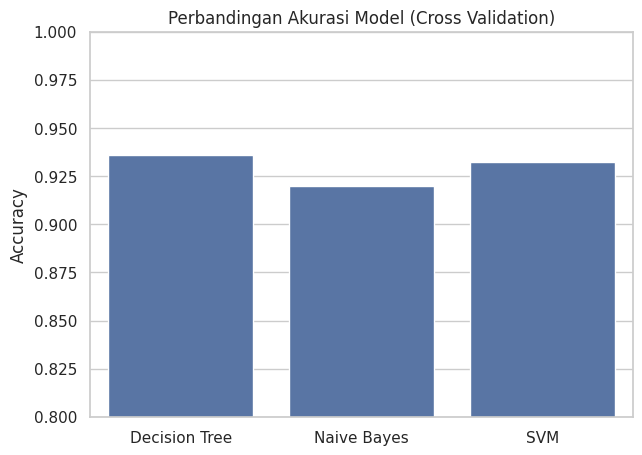

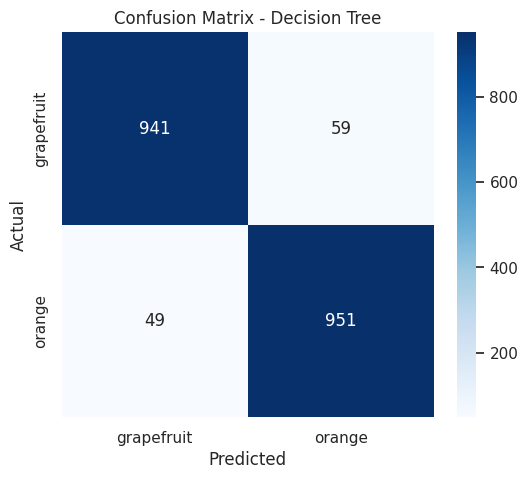

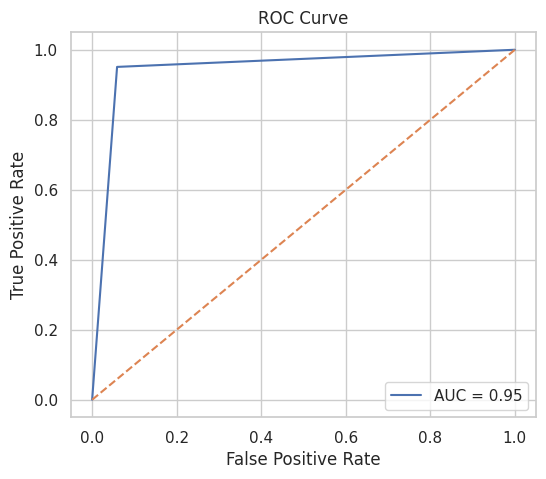

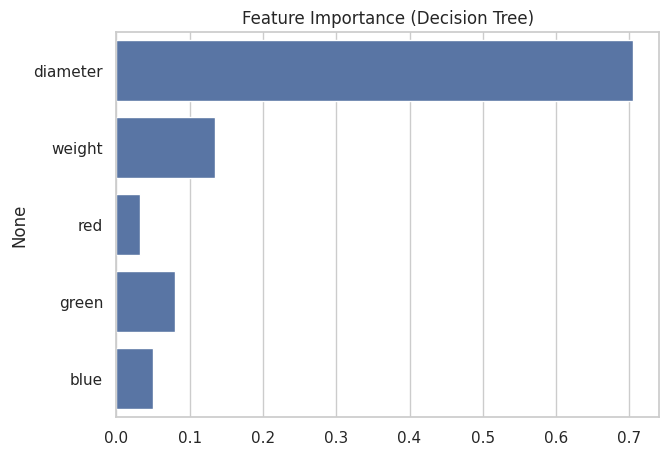


KESIMPULAN:
Model terbaik adalah Decision Tree dengan akurasi 0.9359


In [2]:
# =========================================
# 1. INSTALL & IMPORT LIBRARY
# =========================================
!pip install kagglehub -q

import kagglehub
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

sns.set(style="whitegrid")

# =========================================
# 2. LOAD DATASET
# =========================================
path = kagglehub.dataset_download("joshmcadams/oranges-vs-grapefruit")
file_path = os.path.join(path, "citrus.csv")

df = pd.read_csv(file_path)

print("Dataset Loaded!")
print("Shape:", df.shape)
print(df.head())

# =========================================
# 3. EDA (EXPLORATORY DATA ANALYSIS)
# =========================================

# --- Info Dataset
print("\nINFO DATASET")
print(df.info())

print("\nSTATISTIK DESKRIPTIF")
print(df.describe())

# --- Distribusi Label
plt.figure(figsize=(6,4))
sns.countplot(x='name', data=df)
plt.title("Distribusi Kelas Buah")
plt.show()

# --- Histogram semua fitur
df.hist(figsize=(10,8))
plt.suptitle("Distribusi Semua Fitur")
plt.show()

# --- Korelasi
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# --- Pairplot (relasi antar fitur)
sns.pairplot(df, hue='name')
plt.show()

# --- Scatter Diameter vs Weight
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='diameter', y='weight', hue='name')
plt.title("Diameter vs Weight")
plt.show()

# =========================================
# 4. PREPROCESSING
# =========================================
le = LabelEncoder()
df['target'] = le.fit_transform(df['name'])

X = df.drop(columns=['name', 'target'])
y = df['target']

# Split (NO DATA LEAKAGE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 5. PIPELINE MODEL
# =========================================
pipelines = {
    "Decision Tree": Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier())
    ]),
    "Naive Bayes": Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ]),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True))
    ])
}

# =========================================
# 6. CROSS VALIDATION
# =========================================
results = {}

print("\n=== CROSS VALIDATION ===")

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5)
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

# =========================================
# 7. TRAIN MODEL TERBAIK
# =========================================
best_model_name = max(results, key=results.get)
best_model = pipelines[best_model_name]

print(f"\nBest Model: {best_model_name}")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# =========================================
# 8. EVALUASI
# =========================================
print("\n=== EVALUATION ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

# =========================================
# 9. VISUALISASI HASIL MODEL
# =========================================

# --- Barplot Akurasi
plt.figure(figsize=(7,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Perbandingan Akurasi Model (Cross Validation)")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

# --- Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# =========================================
# 10. ROC CURVE
# =========================================
y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# =========================================
# 11. FEATURE IMPORTANCE (Decision Tree Only)
# =========================================
if best_model_name == "Decision Tree":
    importances = best_model.named_steps['model'].feature_importances_
    features = X.columns

    plt.figure(figsize=(7,5))
    sns.barplot(x=importances, y=features)
    plt.title("Feature Importance (Decision Tree)")
    plt.show()

# =========================================
# 12. KESIMPULAN
# =========================================
print("\nKESIMPULAN:")
print(f"Model terbaik adalah {best_model_name} dengan akurasi {results[best_model_name]:.4f}")